In [12]:
# Om något bibliotek saknas:
# !pip install pandas numpy matplotlib tqdm openpyxl

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

pd.set_option("display.max_columns", None)
pd.options.mode.chained_assignment = None

# ============================================================
# FILVÄGAR OCH BLADNAMN
# ============================================================

send_file = r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\send-station.xlsx"
rec_file  = r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\rec-station.xlsx"

keyS_sheet  = "K-nyckel"
dataS_sheet = "Station_K_3x15000"

keyR_sheet  = "F-nyckel"
dataR_sheet = "Station_F_3x15000"

print("send finns:", os.path.exists(send_file))
print("rec finns :", os.path.exists(rec_file))

# ============================================================
# HJÄLPFUNKTIONER
# ============================================================

def read_key_table_safe(filename, sheetname):
    T = pd.read_excel(filename, sheet_name=sheetname, header=None)
    T = T.iloc[:, :2].copy()
    T.columns = ["Parameter", "ID"]
    T = T.dropna()
    return T

def ls_diagnostics(A, Y, beta):
    Y_hat = A @ beta
    resid = Y - Y_hat

    n = len(Y)
    p = A.shape[1]
    dof = max(n - p, 1)

    sigma2 = np.sum(resid**2) / dof
    ATA_inv = np.linalg.pinv(A.T @ A)
    cov_beta = sigma2 * ATA_inv
    se_beta = np.sqrt(np.diag(cov_beta))

    return {
        "residuals_vector": resid,
        "sigma2": sigma2,
        "cov_beta": cov_beta,
        "se_beta": se_beta,
        "dof": dof
    }

def estimate_B_and_K1_3ph(vs_dict, vr_dict, is_dict, ir_dict):
    """
    Full simultan trefas steg 1.

    Parametrar:
    beta1 = [
        Re(K1_L1), Re(K1_L2), Re(K1_L3),
        Im(K1_L1), Im(K1_L2), Im(K1_L3),
        B_L1,      B_L2,      B_L3
    ]
    """
    phases = ["L1", "L2", "L3"]

    Y_parts = []
    A_rows = []

    for ph_idx, ph in enumerate(phases):
        vs = vs_dict[ph]
        vr = vr_dict[ph]
        is_ = is_dict[ph]
        ir = ir_dict[ph]

        ir_re = np.real(ir)
        ir_im = np.imag(ir)

        v_sum = vs + vr
        v_re = np.real(v_sum)
        v_im = np.imag(v_sum)

        # Realdel för denna fas
        for k in range(len(vs)):
            row = np.zeros(9)
            row[ph_idx] = ir_re[k]          # Re(K1_ph)
            row[3 + ph_idx] = -ir_im[k]     # Im(K1_ph)
            row[6 + ph_idx] = 0.5 * v_re[k] # B_ph
            A_rows.append(row)
            Y_parts.append(np.real(is_[k]))

        # Imaginärdel för denna fas
        for k in range(len(vs)):
            row = np.zeros(9)
            row[ph_idx] = ir_im[k]          # Re(K1_ph)
            row[3 + ph_idx] = ir_re[k]      # Im(K1_ph)
            row[6 + ph_idx] = 0.5 * v_im[k] # B_ph
            A_rows.append(row)
            Y_parts.append(np.imag(is_[k]))

    A = np.array(A_rows)
    Y = np.array(Y_parts)

    beta, residuals, rank, s = np.linalg.lstsq(A, Y, rcond=None)
    diag = ls_diagnostics(A, Y, beta)

    return {
        "beta": beta,
        "rank": rank,
        "singular_values": s,
        "A": A,
        "Y": Y,
        "cov_beta": diag["cov_beta"],
        "se_beta": diag["se_beta"],
        "sigma2": diag["sigma2"]
    }

def estimate_Z_and_K4_3ph(vs_dict, vr_dict, ir_dict, B_dict):
    """
    Full simultan trefas steg 2.

    Parametrar:
    beta2 = [
        Re(K4_L1), Re(K4_L2), Re(K4_L3),
        Im(K4_L1), Im(K4_L2), Im(K4_L3),
        R_L1,      R_L2,      R_L3,
        X_L1,      X_L2,      X_L3
    ]
    """
    phases = ["L1", "L2", "L3"]

    Y_parts = []
    A_rows = []

    Ieq_dict = {}

    for ph in phases:
        Ieq_dict[ph] = ir_dict[ph] + 1j * (B_dict[ph] / 2.0) * vr_dict[ph]

    for ph_idx, ph in enumerate(phases):
        vs = vs_dict[ph]
        vr = vr_dict[ph]
        Ieq = Ieq_dict[ph]

        vr_re = np.real(vr)
        vr_im = np.imag(vr)

        ieq_re = np.real(Ieq)
        ieq_im = np.imag(Ieq)

        # Realdel
        for k in range(len(vs)):
            row = np.zeros(12)
            row[ph_idx] = vr_re[k]            # Re(K4_ph)
            row[3 + ph_idx] = -vr_im[k]       # Im(K4_ph)
            row[6 + ph_idx] = ieq_re[k]       # R_ph
            row[9 + ph_idx] = -ieq_im[k]      # X_ph
            A_rows.append(row)
            Y_parts.append(np.real(vs[k]))

        # Imaginärdel
        for k in range(len(vs)):
            row = np.zeros(12)
            row[ph_idx] = vr_im[k]            # Re(K4_ph)
            row[3 + ph_idx] = vr_re[k]        # Im(K4_ph)
            row[6 + ph_idx] = ieq_im[k]       # R_ph
            row[9 + ph_idx] = ieq_re[k]       # X_ph
            A_rows.append(row)
            Y_parts.append(np.imag(vs[k]))

    A = np.array(A_rows)
    Y = np.array(Y_parts)

    beta, residuals, rank, s = np.linalg.lstsq(A, Y, rcond=None)
    diag = ls_diagnostics(A, Y, beta)

    return {
        "beta": beta,
        "rank": rank,
        "singular_values": s,
        "A": A,
        "Y": Y,
        "Ieq_dict": Ieq_dict,
        "cov_beta": diag["cov_beta"],
        "se_beta": diag["se_beta"],
        "sigma2": diag["sigma2"]
    }


send finns: True
rec finns : True


In [13]:
# ============================================================
# LÄS NYCKLAR OCH RÅDATA
# ============================================================

keyS = read_key_table_safe(send_file, keyS_sheet)
keyR = read_key_table_safe(rec_file, keyR_sheet)

send = pd.read_excel(send_file, sheet_name=dataS_sheet, header=None)
rec  = pd.read_excel(rec_file,  sheet_name=dataR_sheet, header=None)

send = send.iloc[:, :3].copy()
rec  = rec.iloc[:, :3].copy()

send.columns = ["Timestamp", "ID", "Value"]
rec.columns  = ["Timestamp", "ID", "Value"]

send["Timestamp"] = pd.to_datetime(
    send["Timestamp"],
    format="%Y-%m-%d %H:%M:%S.%f",
    errors="coerce"
)

rec["Timestamp"] = pd.to_datetime(
    rec["Timestamp"],
    format="%Y-%m-%d %H:%M:%S.%f",
    errors="coerce"
)

send = send.dropna(subset=["Timestamp"])
rec  = rec.dropna(subset=["Timestamp"])

print("send tidsintervall:", send["Timestamp"].min(), "->", send["Timestamp"].max())
print("rec  tidsintervall:", rec["Timestamp"].min(), "->", rec["Timestamp"].max())
print("unika timestamps send:", send["Timestamp"].nunique())
print("unika timestamps rec :", rec["Timestamp"].nunique())

# ============================================================
# MAPPA ID TILL PARAMETER, PIVOTERA OCH SYNKA
# ============================================================

send = send.merge(keyS, on="ID", how="inner")
rec  = rec.merge(keyR, on="ID", how="inner")

wideS = send.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")
wideR = rec.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")

wideS = wideS.add_suffix("_S")
wideR = wideR.add_suffix("_R")

df = wideS.join(wideR, how="inner").sort_index().copy()

print("Antal rader wideS:", len(wideS))
print("Antal rader wideR:", len(wideR))
print("Gemensamma timestamps efter join:", len(df))

# ============================================================
# RENSNING
# ============================================================

required_cols = [
    "UL1MAG_S","UL1ANG_S","UL1MAG_R","UL1ANG_R",
    "IL1MAG_S","IL1ANG_S","IL1MAG_R","IL1ANG_R",
    "UL2MAG_S","UL2ANG_S","UL2MAG_R","UL2ANG_R",
    "IL2MAG_S","IL2ANG_S","IL2MAG_R","IL2ANG_R",
    "UL3MAG_S","UL3ANG_S","UL3MAG_R","UL3ANG_R",
    "IL3MAG_S","IL3ANG_S","IL3MAG_R","IL3ANG_R",
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Saknade kolumner: {missing}")

for c in required_cols:
    df[c] = (
        df[c]
        .astype(str)
        .str.strip()
        .str.replace(",", ".", regex=False)
    )
    df[c] = pd.to_numeric(df[c], errors="coerce")

df_clean = df.dropna(subset=required_cols).copy()

print("Rader efter rensning:", len(df_clean))
print("Start:", df_clean.index.min())
print("Slut :", df_clean.index.max())
print("Tidslängd:", df_clean.index.max() - df_clean.index.min())

# ============================================================
# BYGG FASORER - MED INVERTERAD MOTTAGARSTRÖM
# ============================================================

phasors = {}

for ph in ["L1", "L2", "L3"]:
    Vs = df_clean[f"U{ph}MAG_S"] * np.exp(1j * np.deg2rad(df_clean[f"U{ph}ANG_S"]))
    Vr = df_clean[f"U{ph}MAG_R"] * np.exp(1j * np.deg2rad(df_clean[f"U{ph}ANG_R"]))
    Is = df_clean[f"I{ph}MAG_S"] * np.exp(1j * np.deg2rad(df_clean[f"I{ph}ANG_S"]))
    Ir = -df_clean[f"I{ph}MAG_R"] * np.exp(1j * np.deg2rad(df_clean[f"I{ph}ANG_R"]))  # inverterad

    phasors[ph] = {
        "Vs": Vs,
        "Vr": Vr,
        "Is": Is,
        "Ir": Ir,
    }

print("Fasorer skapade för:", list(phasors.keys()))
print("Mottagarström Ir har inverterats.")


send tidsintervall: 2025-12-11 15:25:02.469999 -> 2025-12-11 15:27:32.460000
rec  tidsintervall: 2025-12-11 15:25:02.469999 -> 2025-12-11 15:27:32.459999
unika timestamps send: 15000
unika timestamps rec : 15000
Antal rader wideS: 15000
Antal rader wideR: 15000
Gemensamma timestamps efter join: 7669
Rader efter rensning: 7669
Start: 2025-12-11 15:25:02.469999
Slut : 2025-12-11 15:27:32.450000
Tidslängd: 0 days 00:02:29.980001
Fasorer skapade för: ['L1', 'L2', 'L3']
Mottagarström Ir har inverterats.


In [14]:
# ============================================================
# FÖNSTERINSTÄLLNINGAR
# ============================================================

dt = df_clean.index.to_series().diff().dropna().dt.total_seconds()

print(dt.describe())
print("\nVanligaste tidssteg:")
print(dt.value_counts().head(10))

fs = 1.0 / dt.median()
print(f"\nUppskattad samplingsfrekvens fs = {fs:.3f} Hz")

window_seconds = 120
step_seconds = 5

WINDOW = int(round(window_seconds * fs))
STEP   = int(round(step_seconds * fs))

R_ref = 1.2575
alpha = 0.00403

N = len(df_clean)

print("N =", N)
print("WINDOW =", WINDOW)
print("STEP =", STEP)

if N <= WINDOW:
    raise ValueError(f"För få datapunkter. N={N}, WINDOW={WINDOW}")

idx = np.arange(0, N - WINDOW + 1, STEP)
print("Antal glidfönster =", len(idx))

# ============================================================
# KÖR FULL TREFAS SIMULTAN SINGH
# ============================================================

rows_3ph = []

for i in tqdm(idx, desc="3-ph Singh simultaneous"):
    i0 = i
    i1 = i + WINDOW

    vs_dict = {}
    vr_dict = {}
    is_dict = {}
    ir_dict = {}

    for ph in ["L1", "L2", "L3"]:
        vs_dict[ph] = phasors[ph]["Vs"].iloc[i0:i1].to_numpy()
        vr_dict[ph] = phasors[ph]["Vr"].iloc[i0:i1].to_numpy()
        is_dict[ph] = phasors[ph]["Is"].iloc[i0:i1].to_numpy()
        ir_dict[ph] = phasors[ph]["Ir"].iloc[i0:i1].to_numpy()

    try:
        # Steg 1
        res1 = estimate_B_and_K1_3ph(vs_dict, vr_dict, is_dict, ir_dict)
        beta1 = res1["beta"]

        K1 = {
            "L1": beta1[0] + 1j * beta1[3],
            "L2": beta1[1] + 1j * beta1[4],
            "L3": beta1[2] + 1j * beta1[5],
        }

        B = {
            "L1": beta1[6],
            "L2": beta1[7],
            "L3": beta1[8],
        }

        # Steg 2
        res2 = estimate_Z_and_K4_3ph(vs_dict, vr_dict, ir_dict, B)
        beta2 = res2["beta"]

        K4 = {
            "L1": beta2[0] + 1j * beta2[3],
            "L2": beta2[1] + 1j * beta2[4],
            "L3": beta2[2] + 1j * beta2[5],
        }

        R = {
            "L1": beta2[6],
            "L2": beta2[7],
            "L3": beta2[8],
        }

        X = {
            "L1": beta2[9],
            "L2": beta2[10],
            "L3": beta2[11],
        }

    except np.linalg.LinAlgError:
        continue

    center_ts = df_clean.index[i0 + WINDOW // 2]

    for ph_idx, ph in enumerate(["L1", "L2", "L3"]):
        se_R = res2["se_beta"][6 + ph_idx]
        se_X = res2["se_beta"][9 + ph_idx]

        T_est = ((R[ph] / R_ref) - 1.0) / alpha + 20.0

        dT_dR = 1.0 / (alpha * R_ref)
        u_T = abs(dT_dR) * se_R

        rows_3ph.append({
            "Timestamp": center_ts,
            "Phase": ph,
            "K1_real": np.real(K1[ph]),
            "K1_imag": np.imag(K1[ph]),
            "K4_real": np.real(K4[ph]),
            "K4_imag": np.imag(K4[ph]),
            "B_S": B[ph],
            "R_Ohm": R[ph],
            "X_Ohm": X[ph],
            "u_R_Ohm": se_R,
            "u_X_Ohm": se_X,
            "T_C": T_est,
            "u_T_C": u_T,
            "rank_step1": res1["rank"],
            "rank_step2": res2["rank"]
        })

results_3ph_long = pd.DataFrame(rows_3ph)

print("Antal rader i results_3ph_long:", len(results_3ph_long))
display(results_3ph_long.head())


count    7668.000000
mean        0.019559
std         0.012780
min         0.009998
25%         0.010000
50%         0.019999
75%         0.030000
max         0.140000
Name: Timestamp, dtype: float64

Vanligaste tidssteg:
Timestamp
0.010000    2608
0.030000    1448
0.020000    1438
0.009999     528
0.010001     513
0.020001     292
0.019999     241
0.060000     134
0.040000     119
0.050000      94
Name: count, dtype: int64

Uppskattad samplingsfrekvens fs = 50.003 Hz
N = 7669
WINDOW = 6000
STEP = 250
Antal glidfönster = 7


3-ph Singh simultaneous:   0%|          | 0/7 [00:00<?, ?it/s]

Antal rader i results_3ph_long: 21


,Timestamp,Phase,K1_real,K1_imag,K4_real,K4_imag,B_S,R_Ohm,X_Ohm,u_R_Ohm,u_X_Ohm,T_C,u_T_C,rank_step1,rank_step2
0,2025-12-11 15:26:04.179999,L1,1.002441,0.017093,0.999619,0.000834,0.000016,1.932270,6.411183,0.010053,0.010053,153.150549,1.983805,9,12
1,2025-12-11 15:26:04.179999,L2,0.994724,0.015430,0.999508,0.000744,0.000037,1.333256,5.994489,0.009991,0.009991,34.948778,1.971463,9,12
2,2025-12-11 15:26:04.179999,L3,0.984783,0.021669,0.999391,0.000994,0.000064,0.820024,6.372456,0.010036,0.010036,-66.325941,1.980356,9,12
3,2025-12-11 15:26:08.649999,L1,1.002742,0.017121,0.999611,0.000919,0.000015,1.935204,6.375761,0.010385,0.010385,153.729447,2.049289,9,12
4,2025-12-11 15:26:08.649999,L2,0.994742,0.015541,0.999544,0.000854,0.000037,1.320979,5.949960,0.010314,0.010314,32.526161,2.035270,9,12


In [15]:
# ============================================================
# BRETT FORMAT
# ============================================================

out_3ph = results_3ph_long.pivot(
    index="Timestamp",
    columns="Phase",
    values=[
        "K1_real", "K1_imag",
        "K4_real", "K4_imag",
        "B_S", "R_Ohm", "X_Ohm",
        "u_R_Ohm", "u_X_Ohm",
        "T_C", "u_T_C"
    ]
)

out_3ph.columns = [f"{var}_{ph}" for var, ph in out_3ph.columns]
out_3ph = out_3ph.reset_index().sort_values("Timestamp")

print("HEAD out_3ph:")
display(out_3ph.head())

# Filtrera bort första fönstret för jämförbarhet
out_3ph_filtered = out_3ph.iloc[1:].copy()

print("HEAD out_3ph_filtered:")
display(out_3ph_filtered.head())

# ============================================================
# SUMMARY
# ============================================================

summary_3ph_rows = []

for ph in ["L1", "L2", "L3"]:
    summary_3ph_rows.append({
        "Phase": ph,
        "R_mean_Ohm": out_3ph_filtered[f"R_Ohm_{ph}"].mean(),
        "R_std_Ohm": out_3ph_filtered[f"R_Ohm_{ph}"].std(),
        "R_min_Ohm": out_3ph_filtered[f"R_Ohm_{ph}"].min(),
        "R_max_Ohm": out_3ph_filtered[f"R_Ohm_{ph}"].max(),
        "X_mean_Ohm": out_3ph_filtered[f"X_Ohm_{ph}"].mean(),
        "X_std_Ohm": out_3ph_filtered[f"X_Ohm_{ph}"].std(),
        "T_mean_C": out_3ph_filtered[f"T_C_{ph}"].mean(),
        "T_std_C": out_3ph_filtered[f"T_C_{ph}"].std(),
        "K1_real_mean": out_3ph_filtered[f"K1_real_{ph}"].mean(),
        "K1_imag_mean": out_3ph_filtered[f"K1_imag_{ph}"].mean(),
        "K4_real_mean": out_3ph_filtered[f"K4_real_{ph}"].mean(),
        "K4_imag_mean": out_3ph_filtered[f"K4_imag_{ph}"].mean(),
    })

summary_3ph_df = pd.DataFrame(summary_3ph_rows)

print("SUMMARY 3-PH SIMULTAN:")
display(summary_3ph_df)


HEAD out_3ph:


,Timestamp,K1_real_L1,K1_real_L2,K1_real_L3,K1_imag_L1,K1_imag_L2,K1_imag_L3,K4_real_L1,K4_real_L2,K4_real_L3,K4_imag_L1,K4_imag_L2,K4_imag_L3,B_S_L1,B_S_L2,B_S_L3,R_Ohm_L1,R_Ohm_L2,R_Ohm_L3,X_Ohm_L1,X_Ohm_L2,X_Ohm_L3,u_R_Ohm_L1,u_R_Ohm_L2,u_R_Ohm_L3,u_X_Ohm_L1,u_X_Ohm_L2,u_X_Ohm_L3,T_C_L1,T_C_L2,T_C_L3,u_T_C_L1,u_T_C_L2,u_T_C_L3
0,2025-12-11 15:26:04.179999,1.002441,0.994724,0.984783,0.017093,0.015430,0.021669,0.999619,0.999508,0.999391,0.000834,0.000744,0.000994,0.000016,0.000037,0.000064,1.932270,1.333256,0.820024,6.411183,5.994489,6.372456,0.010053,0.009991,0.010036,0.010053,0.009991,0.010036,153.150549,34.948778,-66.325941,1.983805,1.971463,1.980356
1,2025-12-11 15:26:08.649999,1.002742,0.994742,0.984392,0.017121,0.015541,0.021835,0.999611,0.999544,0.999427,0.000919,0.000854,0.001076,0.000015,0.000037,0.000064,1.935204,1.320979,0.808699,6.375761,5.949960,6.336307,0.010385,0.010314,0.010411,0.010385,0.010314,0.010411,153.729447,32.526161,-68.560701,2.049289,2.035270,2.054429
2,2025-12-11 15:26:14.820000,1.002568,0.994874,0.984116,0.017104,0.015638,0.021959,0.999583,0.999567,0.999408,0.000971,0.000896,0.001101,0.000016,0.000036,0.000065,1.949024,1.312897,0.818731,6.351893,5.930674,6.324321,0.010356,0.010258,0.010415,0.010356,0.010258,0.010415,156.456582,30.931258,-66.581032,2.043521,2.024107,2.055110
3,2025-12-11 15:26:18.849999,1.002204,0.995258,0.983837,0.017067,0.015725,0.022031,0.999594,0.999572,0.999368,0.000985,0.000870,0.001118,0.000016,0.000035,0.000065,1.946158,1.308810,0.836694,6.346066,5.941635,6.319344,0.010121,0.010020,0.010181,0.010121,0.010020,0.010181,155.891030,30.124836,-63.036403,1.997210,1.977192,2.008912
4,2025-12-11 15:26:23.889999,1.002462,0.995971,0.983980,0.017054,0.015811,0.022150,0.999579,0.999543,0.999348,0.000962,0.000852,0.001133,0.000016,0.000033,0.000065,1.951236,1.317636,0.845472,6.354672,5.948619,6.313060,0.009642,0.009525,0.009698,0.009642,0.009525,0.009698,156.893062,31.866377,-61.304334,1.902540,1.879584,1.913644


HEAD out_3ph_filtered:


,Timestamp,K1_real_L1,K1_real_L2,K1_real_L3,K1_imag_L1,K1_imag_L2,K1_imag_L3,K4_real_L1,K4_real_L2,K4_real_L3,K4_imag_L1,K4_imag_L2,K4_imag_L3,B_S_L1,B_S_L2,B_S_L3,R_Ohm_L1,R_Ohm_L2,R_Ohm_L3,X_Ohm_L1,X_Ohm_L2,X_Ohm_L3,u_R_Ohm_L1,u_R_Ohm_L2,u_R_Ohm_L3,u_X_Ohm_L1,u_X_Ohm_L2,u_X_Ohm_L3,T_C_L1,T_C_L2,T_C_L3,u_T_C_L1,u_T_C_L2,u_T_C_L3
1,2025-12-11 15:26:08.649999,1.002742,0.994742,0.984392,0.017121,0.015541,0.021835,0.999611,0.999544,0.999427,0.000919,0.000854,0.001076,0.000015,0.000037,0.000064,1.935204,1.320979,0.808699,6.375761,5.949960,6.336307,0.010385,0.010314,0.010411,0.010385,0.010314,0.010411,153.729447,32.526161,-68.560701,2.049289,2.035270,2.054429
2,2025-12-11 15:26:14.820000,1.002568,0.994874,0.984116,0.017104,0.015638,0.021959,0.999583,0.999567,0.999408,0.000971,0.000896,0.001101,0.000016,0.000036,0.000065,1.949024,1.312897,0.818731,6.351893,5.930674,6.324321,0.010356,0.010258,0.010415,0.010356,0.010258,0.010415,156.456582,30.931258,-66.581032,2.043521,2.024107,2.055110
3,2025-12-11 15:26:18.849999,1.002204,0.995258,0.983837,0.017067,0.015725,0.022031,0.999594,0.999572,0.999368,0.000985,0.000870,0.001118,0.000016,0.000035,0.000065,1.946158,1.308810,0.836694,6.346066,5.941635,6.319344,0.010121,0.010020,0.010181,0.010121,0.010020,0.010181,155.891030,30.124836,-63.036403,1.997210,1.977192,2.008912
4,2025-12-11 15:26:23.889999,1.002462,0.995971,0.983980,0.017054,0.015811,0.022150,0.999579,0.999543,0.999348,0.000962,0.000852,0.001133,0.000016,0.000033,0.000065,1.951236,1.317636,0.845472,6.354672,5.948619,6.313060,0.009642,0.009525,0.009698,0.009642,0.009525,0.009698,156.893062,31.866377,-61.304334,1.902540,1.879584,1.913644
5,2025-12-11 15:26:28.719999,1.003119,0.997179,0.985109,0.017064,0.015920,0.022385,0.999525,0.999503,0.999304,0.000810,0.000712,0.000988,0.000014,0.000030,0.000062,1.969930,1.326243,0.853997,6.419866,6.006481,6.375837,0.009017,0.008890,0.009057,0.009017,0.008890,0.009057,160.581772,33.564870,-59.622100,1.779306,1.754230,1.787260


SUMMARY 3-PH SIMULTAN:


,Phase,R_mean_Ohm,R_std_Ohm,R_min_Ohm,R_max_Ohm,X_mean_Ohm,X_std_Ohm,T_mean_C,T_std_C,K1_real_mean,K1_imag_mean,K4_real_mean,K4_imag_mean
0,L1,1.953719,0.014010,1.935204,1.970761,6.374084,0.029136,157.382935,2.764515,1.002780,0.017077,0.999569,0.000919
1,L2,1.317836,0.006218,1.308810,1.326243,5.960492,0.029124,31.905971,1.226970,0.996056,0.015777,0.999540,0.000824
2,L3,0.835901,0.018481,0.808699,0.853997,6.336911,0.023655,-63.192868,3.646801,0.984503,0.022153,0.999361,0.001076


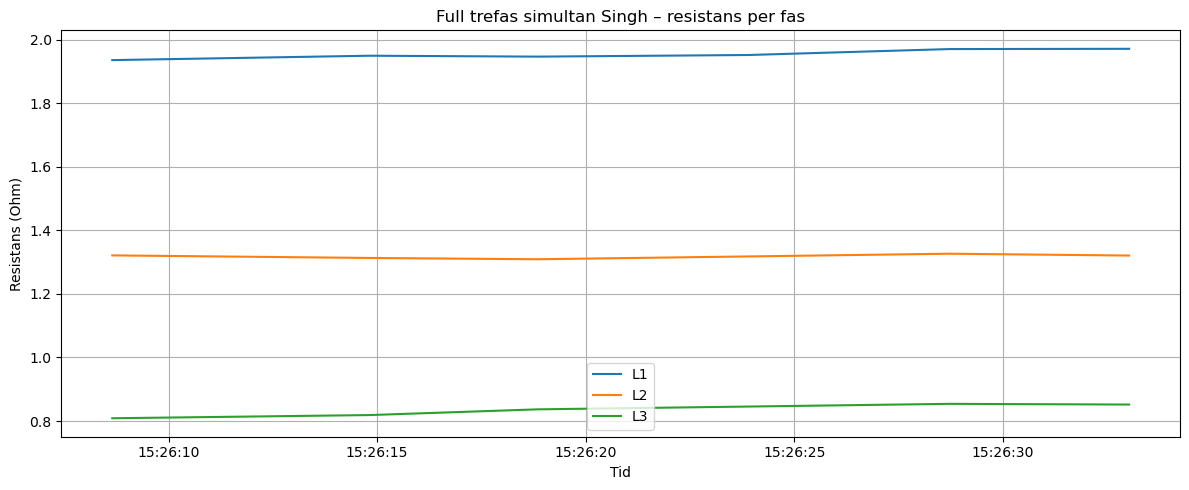

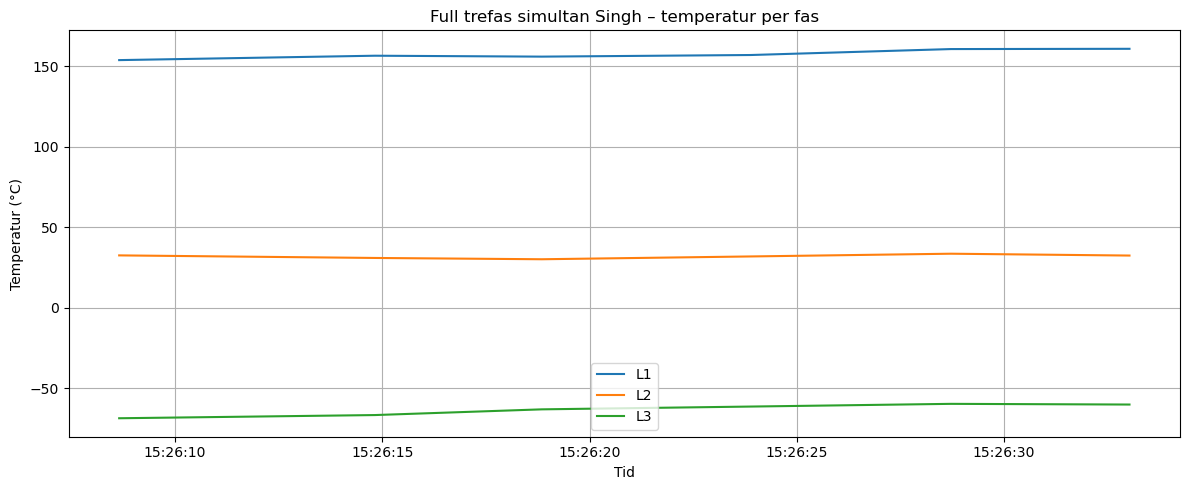

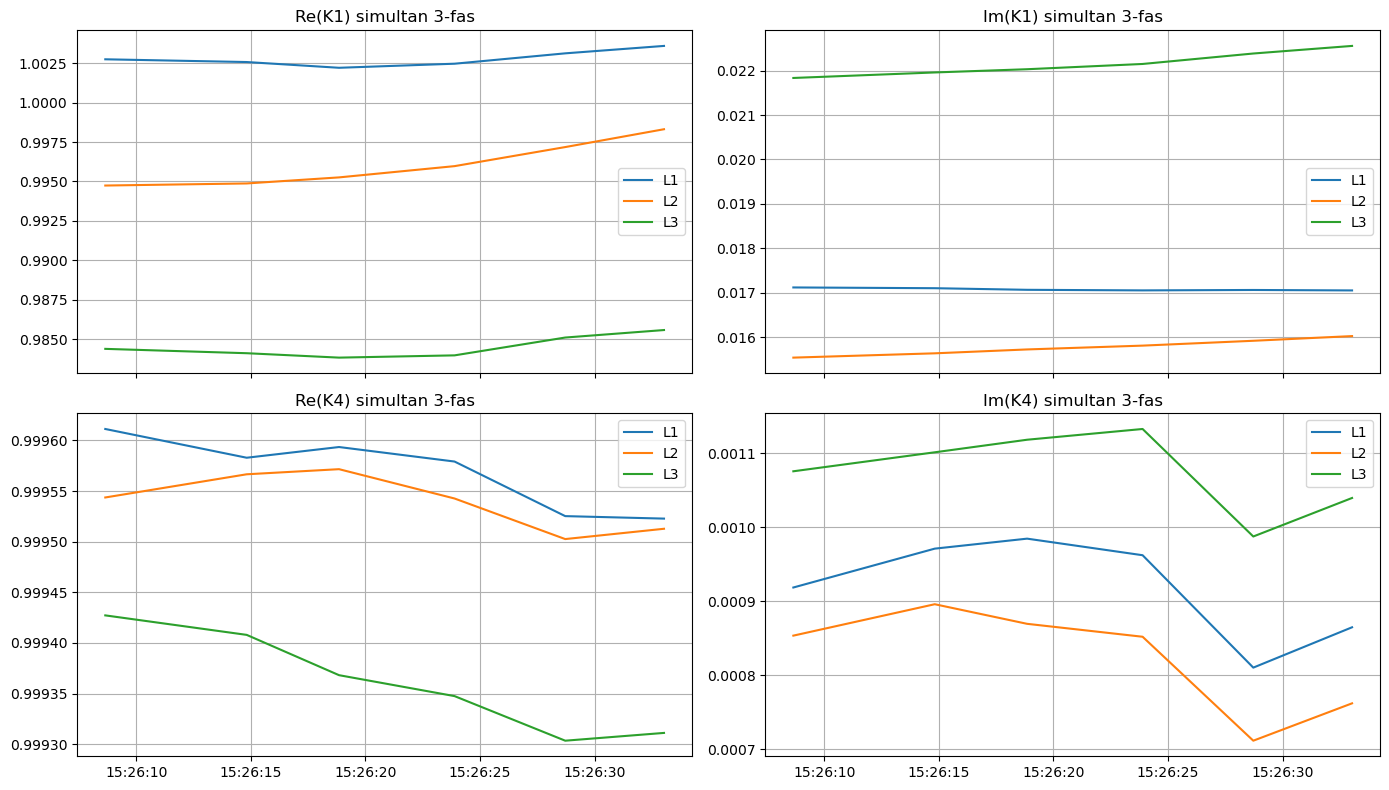

JÄMFÖRELSE MOT R_ref_test:


,Phase,R_mean_Ohm,R_ref_test_Ohm,Absolute_error_Ohm,Relative_error_percent
0,L1,1.953719,1.98,-0.026281,-1.327327
1,L2,1.317836,1.98,-0.662164,-33.442617
2,L3,0.835901,1.98,-1.144099,-57.782756


Sparat till: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\singh_3ph_simultaneous.xlsx

TAIL out_3ph_filtered:


,Timestamp,K1_real_L1,K1_real_L2,K1_real_L3,K1_imag_L1,K1_imag_L2,K1_imag_L3,K4_real_L1,K4_real_L2,K4_real_L3,K4_imag_L1,K4_imag_L2,K4_imag_L3,B_S_L1,B_S_L2,B_S_L3,R_Ohm_L1,R_Ohm_L2,R_Ohm_L3,X_Ohm_L1,X_Ohm_L2,X_Ohm_L3,u_R_Ohm_L1,u_R_Ohm_L2,u_R_Ohm_L3,u_X_Ohm_L1,u_X_Ohm_L2,u_X_Ohm_L3,T_C_L1,T_C_L2,T_C_L3,u_T_C_L1,u_T_C_L2,u_T_C_L3
2,2025-12-11 15:26:14.820000,1.002568,0.994874,0.984116,0.017104,0.015638,0.021959,0.999583,0.999567,0.999408,0.000971,0.000896,0.001101,0.000016,0.000036,0.000065,1.949024,1.312897,0.818731,6.351893,5.930674,6.324321,0.010356,0.010258,0.010415,0.010356,0.010258,0.010415,156.456582,30.931258,-66.581032,2.043521,2.024107,2.055110
3,2025-12-11 15:26:18.849999,1.002204,0.995258,0.983837,0.017067,0.015725,0.022031,0.999594,0.999572,0.999368,0.000985,0.000870,0.001118,0.000016,0.000035,0.000065,1.946158,1.308810,0.836694,6.346066,5.941635,6.319344,0.010121,0.010020,0.010181,0.010121,0.010020,0.010181,155.891030,30.124836,-63.036403,1.997210,1.977192,2.008912
4,2025-12-11 15:26:23.889999,1.002462,0.995971,0.983980,0.017054,0.015811,0.022150,0.999579,0.999543,0.999348,0.000962,0.000852,0.001133,0.000016,0.000033,0.000065,1.951236,1.317636,0.845472,6.354672,5.948619,6.313060,0.009642,0.009525,0.009698,0.009642,0.009525,0.009698,156.893062,31.866377,-61.304334,1.902540,1.879584,1.913644
5,2025-12-11 15:26:28.719999,1.003119,0.997179,0.985109,0.017064,0.015920,0.022385,0.999525,0.999503,0.999304,0.000810,0.000712,0.000988,0.000014,0.000030,0.000062,1.969930,1.326243,0.853997,6.419866,6.006481,6.375837,0.009017,0.008890,0.009057,0.009017,0.008890,0.009057,160.581772,33.564870,-59.622100,1.779306,1.754230,1.787260
6,2025-12-11 15:26:33.029999,1.003589,0.998310,0.985584,0.017053,0.016026,0.022556,0.999523,0.999513,0.999311,0.000865,0.000762,0.001040,0.000013,0.000027,0.000061,1.970761,1.320453,0.851815,6.396250,5.985582,6.352600,0.008310,0.008187,0.008359,0.008310,0.008187,0.008359,160.745717,32.422322,-60.052636,1.639741,1.615592,1.649538


In [16]:
# ============================================================
# PLOTTAR
# ============================================================

plt.figure(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    plt.plot(out_3ph_filtered["Timestamp"], out_3ph_filtered[f"R_Ohm_{ph}"], label=ph)
plt.title("Full trefas simultan Singh – resistans per fas")
plt.xlabel("Tid")
plt.ylabel("Resistans (Ohm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    plt.plot(out_3ph_filtered["Timestamp"], out_3ph_filtered[f"T_C_{ph}"], label=ph)
plt.title("Full trefas simultan Singh – temperatur per fas")
plt.xlabel("Tid")
plt.ylabel("Temperatur (°C)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ph in ["L1", "L2", "L3"]:
    axes[0, 0].plot(out_3ph_filtered["Timestamp"], out_3ph_filtered[f"K1_real_{ph}"], label=ph)
    axes[0, 1].plot(out_3ph_filtered["Timestamp"], out_3ph_filtered[f"K1_imag_{ph}"], label=ph)
    axes[1, 0].plot(out_3ph_filtered["Timestamp"], out_3ph_filtered[f"K4_real_{ph}"], label=ph)
    axes[1, 1].plot(out_3ph_filtered["Timestamp"], out_3ph_filtered[f"K4_imag_{ph}"], label=ph)

axes[0, 0].set_title("Re(K1) simultan 3-fas")
axes[0, 1].set_title("Im(K1) simultan 3-fas")
axes[1, 0].set_title("Re(K4) simultan 3-fas")
axes[1, 1].set_title("Im(K4) simultan 3-fas")

for ax in axes.ravel():
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

# ============================================================
# JÄMFÖRELSE MOT TEST-REFERENS
# ============================================================

R_ref_test = 1.98

comparison_3ph_rows = []

for ph in ["L1", "L2", "L3"]:
    R_mean = out_3ph_filtered[f"R_Ohm_{ph}"].mean()
    abs_err = R_mean - R_ref_test
    rel_err_pct = 100 * abs_err / R_ref_test

    comparison_3ph_rows.append({
        "Phase": ph,
        "R_mean_Ohm": R_mean,
        "R_ref_test_Ohm": R_ref_test,
        "Absolute_error_Ohm": abs_err,
        "Relative_error_percent": rel_err_pct
    })

comparison_3ph_df = pd.DataFrame(comparison_3ph_rows)

print("JÄMFÖRELSE MOT R_ref_test:")
display(comparison_3ph_df)

# ============================================================
# SPARA TILL EXCEL
# ============================================================

output_file = r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\singh_3ph_simultaneous.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    out_3ph.to_excel(writer, sheet_name="Results_3ph", index=False)
    out_3ph_filtered.to_excel(writer, sheet_name="Results_3ph_filtered", index=False)
    summary_3ph_df.to_excel(writer, sheet_name="Summary_3ph", index=False)
    comparison_3ph_df.to_excel(writer, sheet_name="Compare_Rref", index=False)
    results_3ph_long.to_excel(writer, sheet_name="LongFormat", index=False)

print("Sparat till:", output_file)

print("\nTAIL out_3ph_filtered:")
display(out_3ph_filtered.tail())


,count,mean,std,min,25%,50%,75%,max
ΔU_L1_abs,7669.0,3.868850e+02,5.796900e+00,3.701562e+02,3.832500e+02,3.867031e+02,3.899766e+02,4.146641e+02
ΔU_L1_pct,7669.0,4.806000e-01,7.300000e-03,4.594000e-01,4.761000e-01,4.804000e-01,4.845000e-01,5.153000e-01
ΔI_L1_abs,7669.0,1.770600e+00,1.578000e-01,1.077100e+00,1.664400e+00,1.771800e+00,1.878300e+00,2.350500e+00
ΔI_L1_pct,7669.0,9.347000e-01,8.370000e-02,5.844000e-01,8.782000e-01,9.340000e-01,9.907000e-01,1.255600e+00
ΔU_L1_deg,7669.0,8.988000e-01,3.710000e-02,8.143000e-01,8.682000e-01,9.038000e-01,9.266000e-01,9.934000e-01
ΔI_L1_deg,7669.0,-1.790156e+02,4.800000e-02,-1.792241e+02,-1.790482e+02,-1.790158e+02,-1.789828e+02,-1.788376e+02
ΔU_L2_abs,7669.0,3.174279e+02,4.890100e+00,3.015547e+02,3.140859e+02,3.169297e+02,3.204922e+02,3.391328e+02
ΔU_L2_pct,7669.0,3.940000e-01,6.100000e-03,3.744000e-01,3.898000e-01,3.934000e-01,3.978000e-01,4.215000e-01
ΔI_L2_abs,7669.0,1.909000e+00,1.645000e-01,1.331100e+00,1.797400e+00,1.910900e+00,2.018500e+00,2.519300e+00
ΔI_L2_pct,7669.0,9.555000e-01,8.200000e-02,6.777000e-01,9.009000e-01,9.543000e-01,1.010300e+00,1.259300e+00


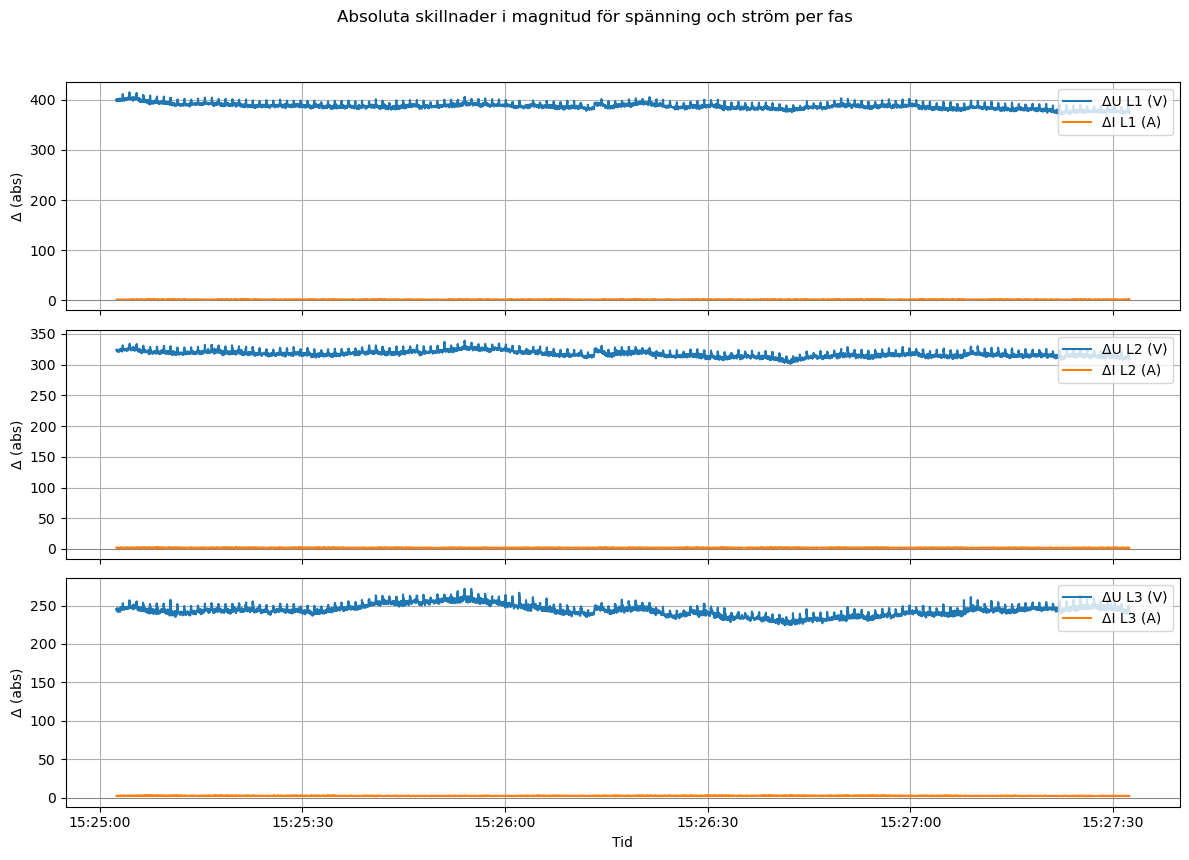

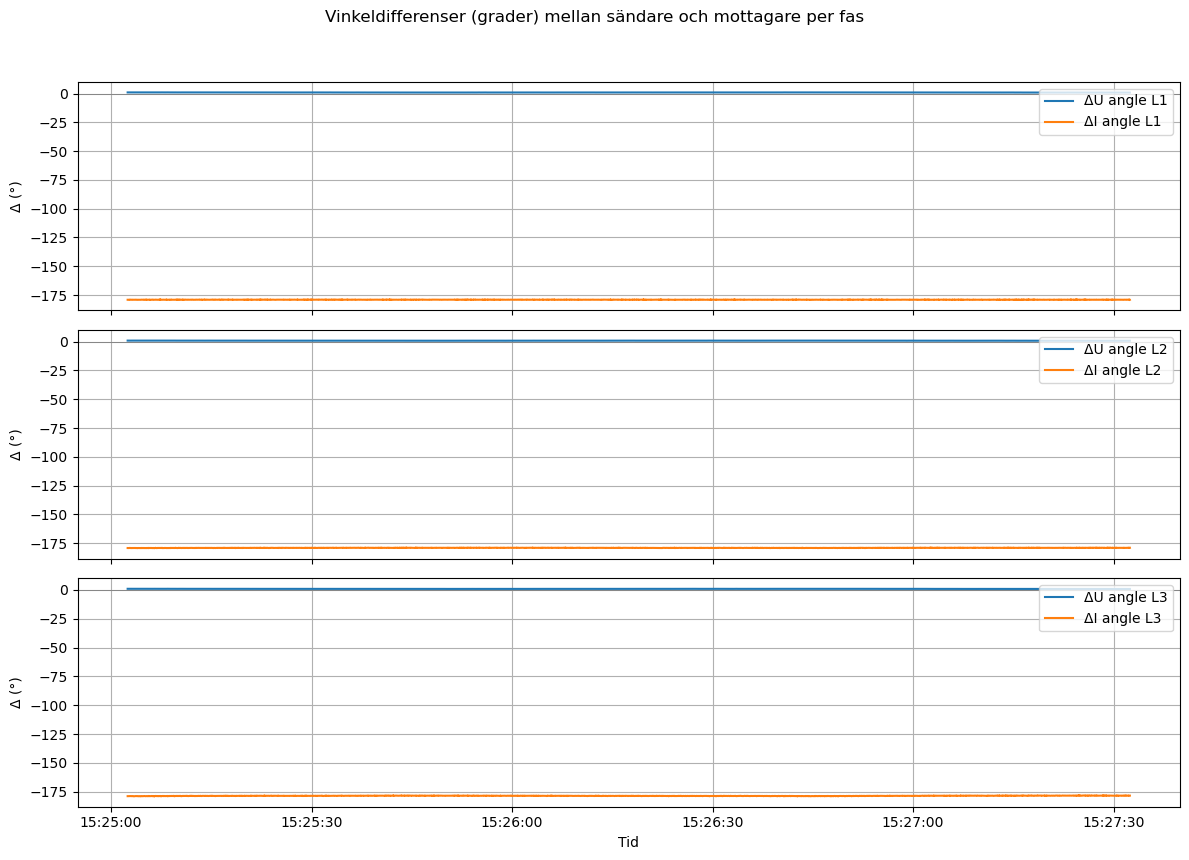

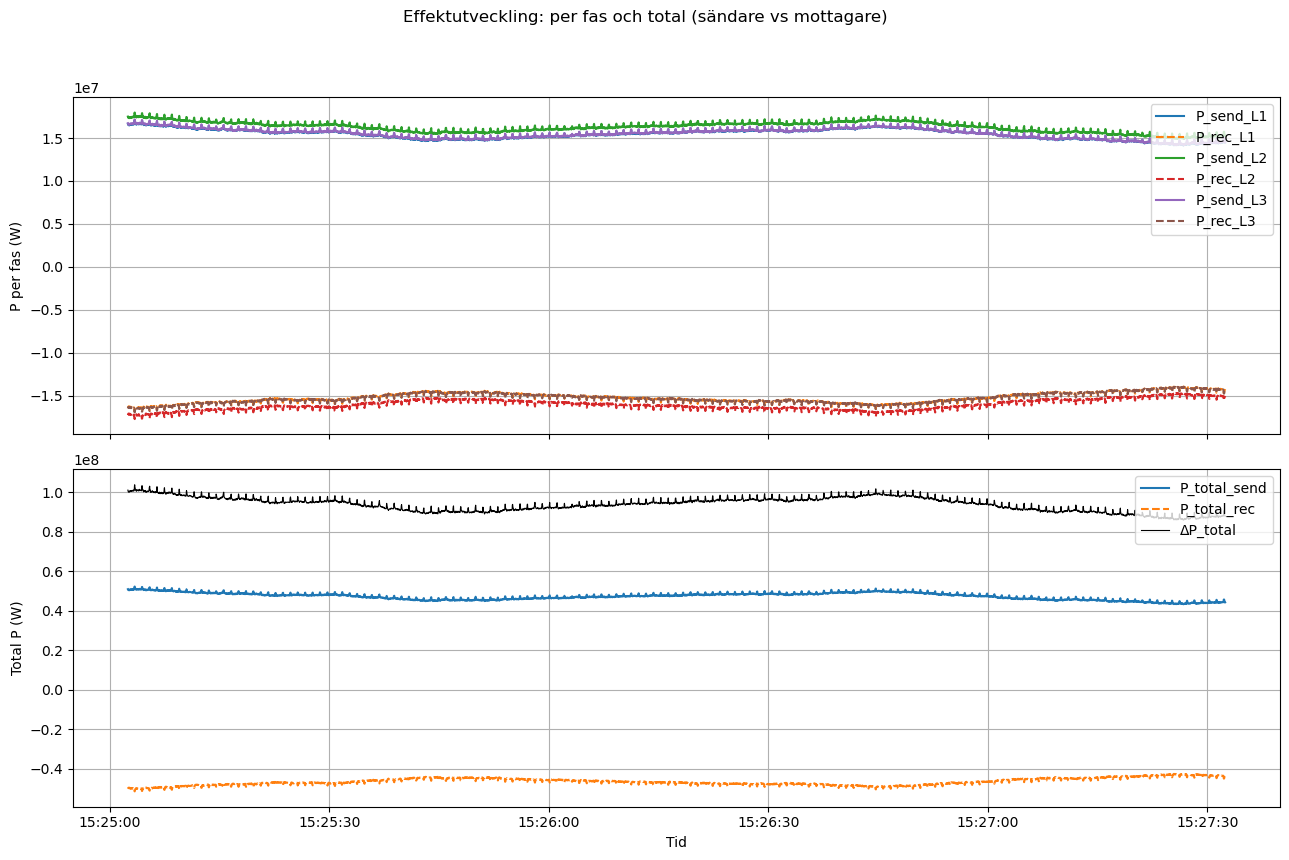

C:\Users\lundi\AppData\Local\Temp\ipykernel_156488\1805593137.py:152: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[1].boxplot([diff_df[f"ΔU_{ph}_abs"].dropna() for ph in phases], labels=phases); axs[1].set_title("Boxplot ΔU per fas (V)")
C:\Users\lundi\AppData\Local\Temp\ipykernel_156488\1805593137.py:154: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[3].boxplot([diff_df[f"ΔI_{ph}_abs"].dropna() for ph in phases], labels=phases); axs[3].set_title("Boxplot ΔI per fas (A)")


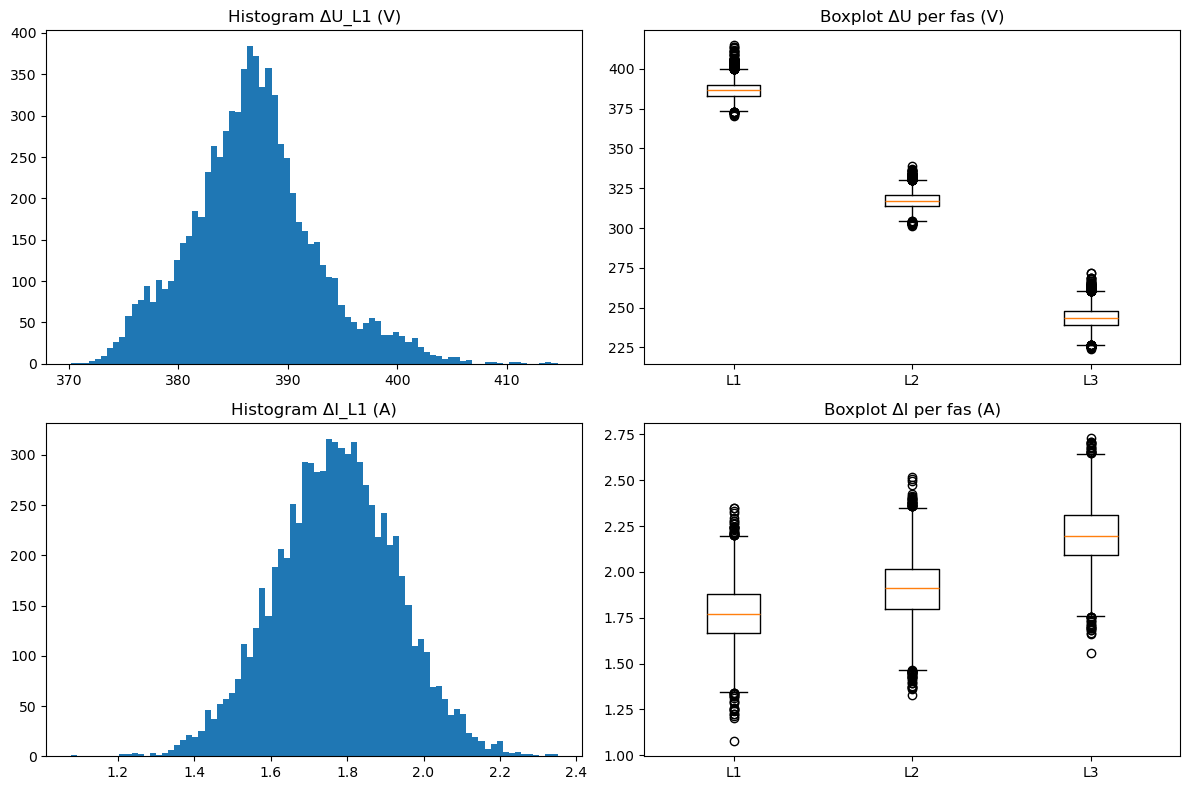

Klar — plots skapade och diff_df finns i minnet.


In [17]:
# ---- Ny cell: Plotta skillnader mellan send och rec ----
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Hjälpfunktioner
def wrap_angle_deg(angle_deg):
    """Wrap angles to [-180, 180] grader (array-kompatibel)."""
    a = (angle_deg + 180) % 360 - 180
    return a

def ensure_numeric_and_clean(df, cols):
    """Säkerställ numeriska kolumner; konvertera komma->punkt och to_numeric."""
    for c in cols:
        if c in df.columns:
            df[c] = df[c].astype(str).str.replace(",", ".", regex=False)
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def build_phasor(mag, ang_deg):
    """Bygg komplex phasor från magnitud (RMS) och vinkel (grader)."""
    return mag * np.exp(1j * np.deg2rad(ang_deg))

# ---- Kontrollera att df_clean finns ----
try:
    df_clean
except NameError:
    raise RuntimeError("df_clean finns inte i minnet. Kör cellerna som skapar df_clean först.")

# ---- Ange faser och förväntade kolumner ----
phases = ["L1", "L2", "L3"]
cols_expected = []
for ph in phases:
    cols_expected += [
        f"U{ph}MAG_S", f"U{ph}ANG_S", f"U{ph}MAG_R", f"U{ph}ANG_R",
        f"I{ph}MAG_S", f"I{ph}ANG_S", f"I{ph}MAG_R", f"I{ph}ANG_R",
    ]

missing = [c for c in cols_expected if c not in df_clean.columns]
if missing:
    raise ValueError(f"Saknade kolumner i df_clean: {missing}")

# Kopiera och sanitera
df = df_clean.copy()
df = ensure_numeric_and_clean(df, cols_expected)

# Bygg diff_df med skillnader och effekt
diff_df = pd.DataFrame(index=df.index)

for ph in phases:
    # Läs kolumner
    U_s_mag = df[f"U{ph}MAG_S"]
    U_s_ang = df[f"U{ph}ANG_S"]
    U_r_mag = df[f"U{ph}MAG_R"]
    U_r_ang = df[f"U{ph}ANG_R"]

    I_s_mag = df[f"I{ph}MAG_S"]
    I_s_ang = df[f"I{ph}ANG_S"]
    I_r_mag = df[f"I{ph}MAG_R"]
    I_r_ang = df[f"I{ph}ANG_R"]

    # Absolut- och procentskillnader
    diff_df[f"ΔU_{ph}_abs"] = U_s_mag - U_r_mag
    diff_df[f"ΔU_{ph}_pct"] = 100.0 * diff_df[f"ΔU_{ph}_abs"] / U_r_mag.replace({0: np.nan})

    diff_df[f"ΔI_{ph}_abs"] = I_s_mag - I_r_mag
    diff_df[f"ΔI_{ph}_pct"] = 100.0 * diff_df[f"ΔI_{ph}_abs"] / I_r_mag.replace({0: np.nan})

    # Vinkeldifferens (grader), omslaget görs så skillnaden hamnar i [-180,180]
    ang_diff_U = wrap_angle_deg(U_s_ang - U_r_ang)
    ang_diff_I = wrap_angle_deg(I_s_ang - I_r_ang)
    diff_df[f"ΔU_{ph}_deg"] = ang_diff_U
    diff_df[f"ΔI_{ph}_deg"] = ang_diff_I

    # Bygg phasors
    Vs = build_phasor(U_s_mag, U_s_ang)
    Vr = build_phasor(U_r_mag, U_r_ang)
    Is_ = build_phasor(I_s_mag, I_s_ang)
    Ir = build_phasor(I_r_mag, I_r_ang)

    # Om du använder samma konvention som i tidigare cell (inverterad mottagarström),
    # avkommentera nästa rad:
    # Ir = -Ir

    # Per-fas aktiv effekt (P = Re(V * conj(I)))
    diff_df[f"P_send_{ph}"] = np.real(Vs * np.conj(Is_))
    diff_df[f"P_rec_{ph}"]  = np.real(Vr * np.conj(Ir))

# Total aktiv effekt (summa av faser)
diff_df["P_total_send"] = diff_df[[f"P_send_{ph}" for ph in phases]].sum(axis=1)
diff_df["P_total_rec"]  = diff_df[[f"P_rec_{ph}" for ph in phases]].sum(axis=1)
diff_df["ΔP_total"] = diff_df["P_total_send"] - diff_df["P_total_rec"]

# Enkel sammanfattande statistik
display(diff_df[[c for c in diff_df.columns if (c.startswith("ΔU") or c.startswith("ΔI") or c.startswith("ΔP"))]].describe().T.round(4))

# ---- Plotta: magnitudskillnader (ΔU och ΔI) ----
plt.rcParams.update({"figure.figsize": (12, 9)})
fig, axs = plt.subplots(3, 1, sharex=True)
for i, ph in enumerate(phases):
    axs[i].plot(diff_df.index, diff_df[f"ΔU_{ph}_abs"], label=f"ΔU {ph} (V)")
    axs[i].plot(diff_df.index, diff_df[f"ΔI_{ph}_abs"], label=f"ΔI {ph} (A)")
    axs[i].axhline(0, color="gray", linewidth=0.6)
    axs[i].set_ylabel("Δ (abs)")
    axs[i].legend(loc="upper right")
    axs[i].grid(True)
axs[-1].set_xlabel("Tid")
plt.suptitle("Absoluta skillnader i magnitud för spänning och ström per fas")
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()

# ---- Plotta: vinkeldifferenser (grader) ----
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(12, 9))
for i, ph in enumerate(phases):
    axs[i].plot(diff_df.index, diff_df[f"ΔU_{ph}_deg"], label=f"ΔU angle {ph}")
    axs[i].plot(diff_df.index, diff_df[f"ΔI_{ph}_deg"], label=f"ΔI angle {ph}")
    axs[i].axhline(0, color="gray", linewidth=0.6)
    axs[i].set_ylabel("Δ (°)")
    axs[i].legend(loc="upper right")
    axs[i].grid(True)
axs[-1].set_xlabel("Tid")
plt.suptitle("Vinkeldifferenser (grader) mellan sändare och mottagare per fas")
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()

# ---- Plotta: effekt per fas och total ----
fig, ax = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
for ph in phases:
    ax[0].plot(diff_df.index, diff_df[f"P_send_{ph}"], label=f"P_send_{ph}")
    ax[0].plot(diff_df.index, diff_df[f"P_rec_{ph}"], linestyle="--", label=f"P_rec_{ph}")
ax[0].legend(loc="upper right")
ax[0].set_ylabel("P per fas (W)")
ax[0].grid(True)

ax[1].plot(diff_df.index, diff_df["P_total_send"], label="P_total_send")
ax[1].plot(diff_df.index, diff_df["P_total_rec"], label="P_total_rec", linestyle="--")
ax[1].plot(diff_df.index, diff_df["ΔP_total"], label="ΔP_total", color="black", linewidth=0.8)
ax[1].legend(loc="upper right")
ax[1].set_ylabel("Total P (W)")
ax[1].set_xlabel("Tid")
ax[1].grid(True)

plt.suptitle("Effektutveckling: per fas och total (sändare vs mottagare)")
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()

# ---- Histogram / boxplot av skillnader (exempel) ----
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.ravel()
axs[0].hist(diff_df["ΔU_L1_abs"].dropna(), bins=80); axs[0].set_title("Histogram ΔU_L1 (V)")
axs[1].boxplot([diff_df[f"ΔU_{ph}_abs"].dropna() for ph in phases], labels=phases); axs[1].set_title("Boxplot ΔU per fas (V)")
axs[2].hist(diff_df["ΔI_L1_abs"].dropna(), bins=80); axs[2].set_title("Histogram ΔI_L1 (A)")
axs[3].boxplot([diff_df[f"ΔI_{ph}_abs"].dropna() for ph in phases], labels=phases); axs[3].set_title("Boxplot ΔI per fas (A)")
plt.tight_layout()
plt.show()

# ---- Valfritt: spara diff_df ----
# diff_df.to_excel("diffs_send_rec.xlsx")
print("Klar — plots skapade och diff_df finns i minnet.")

In [18]:
# ---- Synka send & rec robustt ----
%matplotlib inline
import pandas as pd
import numpy as np

# Antag: du har redan läst in send och rec DataFrames med kolumn "Timestamp"
# Om inte: ladda dem här (exempel):
# send = pd.read_excel("send.xlsx")
# rec  = pd.read_excel("rec.xlsx")

# 0) backup (valfritt men rekommenderat)
send_orig = send.copy()
rec_orig  = rec.copy()

# 1) konvertera Timestamp till datetime och dropna
for df, name in [(send, "send"), (rec, "rec")]:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    n_before = len(df)
    df.dropna(subset=['Timestamp'], inplace=True)
    print(f"{name}: rader före={n_before}, efter dropna Timestamp={len(df)}")

# 2) räkna unika tidstämplar och dubbletter
print("\nUnika timestamps / dubbletter:")
for df, name in [(send, "send"), (rec, "rec")]:
    uniq = df['Timestamp'].nunique()
    total = len(df)
    dups = total - uniq
    print(f"{name}: total={total}, unika={uniq}, dubbletter={dups}")
    if dups>0:
        print("Exempel dubbletter (Timestamp, count):")
        print(df['Timestamp'].value_counts().head(5))

# 3) (valfritt) om du bestämmer dig för att ta bort dubbla timestamps, välj policy:
#    - keep='first' eller keep='last' eller aggregate (t.ex. mean)
# Exempel: ta första raden per Timestamp för att göra index unikt:
send_nd = send.drop_duplicates(subset=['Timestamp'], keep='first').copy()
rec_nd  = rec.drop_duplicates(subset=['Timestamp'], keep='first').copy()
print("\nEfter drop_duplicates (first): send_nd:", len(send_nd), " rec_nd:", len(rec_nd))

# 4) Runda timestamps till en rimlig upplösning (t.ex. 1s eller 100ms) om lämpligt
#    Justera 'round_to' till '1s', '100ms', '10ms' beroende på dina data
round_to = '1s'   # <- byt vid behov
send_nd['Timestamp_round'] = send_nd['Timestamp'].dt.round(round_to)
rec_nd['Timestamp_round']  = rec_nd['Timestamp'].dt.round(round_to)
print("\nExempel rundade timestamps (första 5):")
display(send_nd[['Timestamp','Timestamp_round']].head())
display(rec_nd[['Timestamp','Timestamp_round']].head())

# 5) Sortera på Timestamp (krav för merge_asof)
send_sorted = send_nd.sort_values('Timestamp_round').reset_index(drop=True)
rec_sorted  = rec_nd.sort_values('Timestamp_round').reset_index(drop=True)

# 6) Använd merge_asof för att matcha närmaste tidsstämpel med tolerans
#    Välj tolerance beroende på din datakvalitet (ex '0.5s', '1s', '2s')
tolerance = pd.Timedelta("1s")   # <- byt vid behov
merged = pd.merge_asof(
    send_sorted, rec_sorted,
    left_on='Timestamp_round', right_on='Timestamp_round',
    direction='nearest',
    tolerance=tolerance,
    suffixes=('_S','_R')
)

# 7) Statistik: hur många fick en match (rec-kolumn ej NaN) 
#    Anta att rec har kolumn 'ID' eller annan obligatorisk kolumn; välj en kolumn som indikerar match
rec_indicator_col = None
for c in rec_sorted.columns:
    if c not in send_sorted.columns and c != 'Timestamp_round':
        rec_indicator_col = c
        break
# Fallback: använd 'Timestamp' från rec (Timestamp_R)
if rec_indicator_col is None:
    rec_indicator_col = 'Timestamp_R'  # merge_asof kommer skapa Timestamp_R om names korsar

matched = merged[merged[[col for col in merged.columns if col.endswith('_R')]].notna().any(axis=1)]
num_matched = len(matched)
total_send = len(send_sorted)
print(f"\nMatched (within {tolerance}) = {num_matched} / {total_send} send-rader ({100*num_matched/total_send:.1f}%)")

# 8) Visa exempel på icke-matcherade (nära/ej nära)
unmatched = merged[merged[[col for col in merged.columns if col.endswith('_R')]].isna().all(axis=1)]
print("Exempel icke-matcherade (första 10):")
display(unmatched[['Timestamp_round','Timestamp_S']].head(10))

# 9) Skapa slutlig df_synced: välj strategi
#    A) Keep only matched:
df_synced = matched.copy()
#    B) Om du hellre vill behålla ALLA och fylla saknat med NaN, använd merged som är outer-like

print("\ndf_synced klar. Kolumnexempel:", list(df_synced.columns)[:10])
# Spara om du vill:
# df_synced.to_excel("merged_send_rec_synced.xlsx", index=False)

send: rader före=180000, efter dropna Timestamp=180000
rec: rader före=180000, efter dropna Timestamp=180000

Unika timestamps / dubbletter:
send: total=180000, unika=15000, dubbletter=165000
Exempel dubbletter (Timestamp, count):
Timestamp
2025-12-11 15:25:02.469999    12
2025-12-11 15:26:42.509999    12
2025-12-11 15:26:42.389999    12
2025-12-11 15:26:42.399999    12
2025-12-11 15:26:42.409999    12
Name: count, dtype: int64
rec: total=180000, unika=15000, dubbletter=165000
Exempel dubbletter (Timestamp, count):
Timestamp
2025-12-11 15:25:02.469999    12
2025-12-11 15:26:42.509999    12
2025-12-11 15:26:42.389999    12
2025-12-11 15:26:42.399999    12
2025-12-11 15:26:42.410000    12
Name: count, dtype: int64

Efter drop_duplicates (first): send_nd: 15000  rec_nd: 15000

Exempel rundade timestamps (första 5):


,Timestamp,Timestamp_round
0,2025-12-11 15:25:02.469999,2025-12-11 15:25:02
12,2025-12-11 15:25:02.480001,2025-12-11 15:25:02
24,2025-12-11 15:25:02.490000,2025-12-11 15:25:02
36,2025-12-11 15:25:02.499999,2025-12-11 15:25:02
48,2025-12-11 15:25:02.509999,2025-12-11 15:25:03


,Timestamp,Timestamp_round
0,2025-12-11 15:25:02.469999,2025-12-11 15:25:02
12,2025-12-11 15:25:02.479999,2025-12-11 15:25:02
24,2025-12-11 15:25:02.489999,2025-12-11 15:25:02
36,2025-12-11 15:25:02.499999,2025-12-11 15:25:02
48,2025-12-11 15:25:02.509999,2025-12-11 15:25:03



Matched (within 0 days 00:00:01) = 15000 / 15000 send-rader (100.0%)
Exempel icke-matcherade (första 10):


,Timestamp_round,Timestamp_S



df_synced klar. Kolumnexempel: ['Timestamp_S', 'ID_S', 'Value_S', 'Parameter_S', 'Timestamp_round', 'Timestamp_R', 'ID_R', 'Value_R', 'Parameter_R']


In [19]:
print("Bohus R_ref =", 0.0729 * 17.25)
print("Gota  R_ref =", 0.0348 * 21.95)

for ph in ["L1", "L2", "L3"]:
    print(ph, out_3ph_filtered[f"R_Ohm_{ph}"].mean())

Bohus R_ref = 1.257525
Gota  R_ref = 0.7638599999999999
L1 1.953718934396668
L2 1.3178361854400829
L3 0.8359014233373424


In [20]:
print("=== Medelvärden per fas ===")
for ph in ["L1", "L2", "L3"]:
    print(
        ph,
        "R_mean =", out_3ph_filtered[f"R_Ohm_{ph}"].mean(),
        "R_std =", out_3ph_filtered[f"R_Ohm_{ph}"].std(),
        "X_mean =", out_3ph_filtered[f"X_Ohm_{ph}"].mean(),
        "u_R_mean =", out_3ph_filtered[f"u_R_Ohm_{ph}"].mean()
    )

print("\n=== Bohus/Gota referenser ===")
print("Bohus R_ref =", 0.0729 * 17.25)
print("Gota  R_ref =", 0.0348 * 21.95)

=== Medelvärden per fas ===
L1 R_mean = 1.953718934396668 R_std = 0.01400980287679713 X_mean = 6.374084480485205 u_R_mean = 0.009638480476263209
L2 R_mean = 1.3178361854400829 R_std = 0.006217946695869098 X_mean = 5.960491861211849 u_R_mean = 0.00953236823550717
L3 R_mean = 0.8359014233373424 R_std = 0.018480982417139597 X_mean = 6.336911447413478 u_R_mean = 0.009686865906301596

=== Bohus/Gota referenser ===
Bohus R_ref = 1.257525
Gota  R_ref = 0.7638599999999999


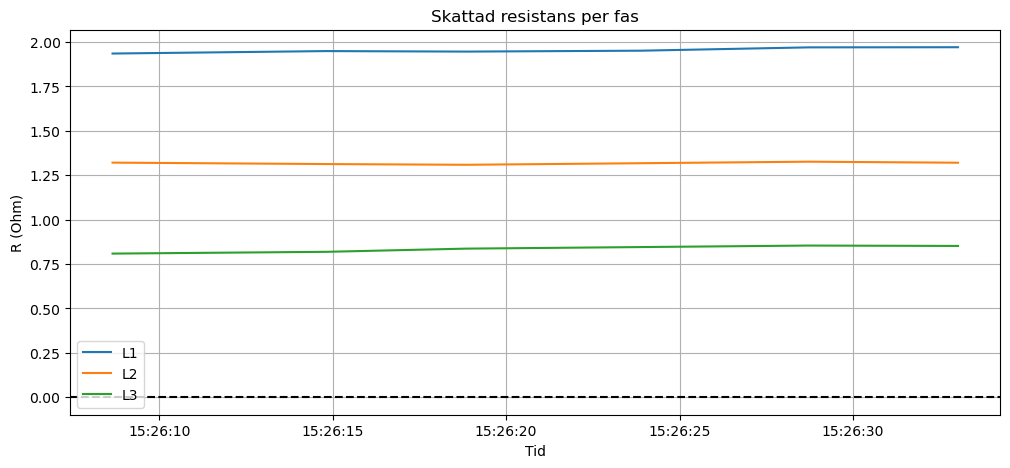

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
for ph in ["L1","L2","L3"]:
    plt.plot(out_3ph_filtered["Timestamp"], out_3ph_filtered[f"R_Ohm_{ph}"], label=ph)
plt.axhline(0, color="black", linestyle="--")
plt.title("Skattad resistans per fas")
plt.ylabel("R (Ohm)")
plt.xlabel("Tid")
plt.grid(True)
plt.legend()
plt.show()

In [22]:
def wrap_angle_deg(a):
    return (a + 180) % 360 - 180

for ph in ["L1", "L2", "L3"]:
    I_r_ang_corr = wrap_angle_deg(df_clean[f"I{ph}ANG_R"] + 180.0)
    dI_corr = wrap_angle_deg(df_clean[f"I{ph}ANG_S"] - I_r_ang_corr)
    dU = wrap_angle_deg(df_clean[f"U{ph}ANG_S"] - df_clean[f"U{ph}ANG_R"])

    print(ph, "mean ΔU =", dU.mean(), "mean ΔI_corr =", dI_corr.mean())

L1 mean ΔU = 0.8987697766549686 mean ΔI_corr = 0.9844170869472725
L2 mean ΔU = 0.8759890024848692 mean ΔI_corr = 0.9545636475791154
L3 mean ΔU = 0.8987592451512287 mean ΔI_corr = 1.4597826978781854
